# Credit Risk PD Model

## Load Data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("application_train.csv")


In [3]:
print(df.shape)


(307511, 122)


In [4]:
print(df["TARGET"].value_counts())

TARGET
0    282686
1     24825
Name: count, dtype: int64


## Reduce Size 

In [6]:
df = df.sample(70000, random_state=42)
print(df.shape)

(70000, 122)


## Keep Numeric Columns Only

In [7]:
df_numeric = df.select_dtypes(include=["int64","float64"])
print(df_numeric.shape)

(70000, 106)


## Target & Features

In [8]:
y = df_numeric["TARGET"]
X = df_numeric.drop("TARGET", axis=1)

## Missing Values

In [9]:
X = X.fillna(X.median())

## Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## Logistic Regression (Interpretability Model)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=3000
)

log_model.fit(X_train, y_train)

log_probs = log_model.predict_proba(X_test)[:,1]

print("Logistic ROC-AUC:", roc_auc_score(y_test, log_probs))

Logistic ROC-AUC: 0.6127681226714139


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Random Forest (Performance Model)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)[:,1]

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_probs))

Random Forest ROC-AUC: 0.6971747164350915


## Threshold Optimization

In [13]:
from sklearn.metrics import confusion_matrix

threshold = 0.30

rf_pred = (rf_probs >= threshold).astype(int)

print(confusion_matrix(y_test, rf_pred))

[[19115   194]
 [ 1583   108]]


## Feature Importance

In [14]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

print(importance.sort_values(ascending=False).head(10))

EXT_SOURCE_2              0.082239
EXT_SOURCE_3              0.073034
DAYS_BIRTH                0.043132
DAYS_EMPLOYED             0.039804
DAYS_LAST_PHONE_CHANGE    0.039401
DAYS_REGISTRATION         0.036980
DAYS_ID_PUBLISH           0.036615
SK_ID_CURR                0.036342
EXT_SOURCE_1              0.035869
AMT_ANNUITY               0.035742
dtype: float64


## ROC Plot

In [16]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


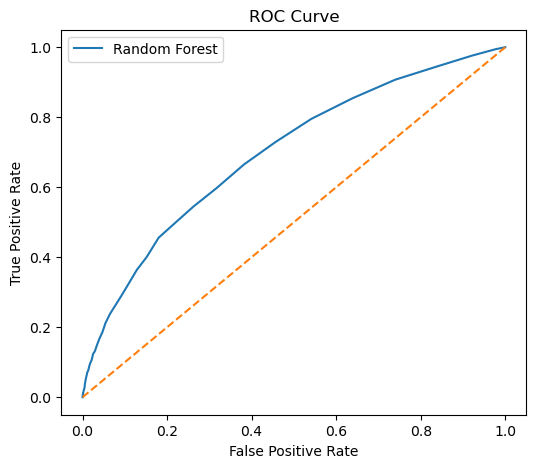

In [18]:
fpr, tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Default Rate Chart 

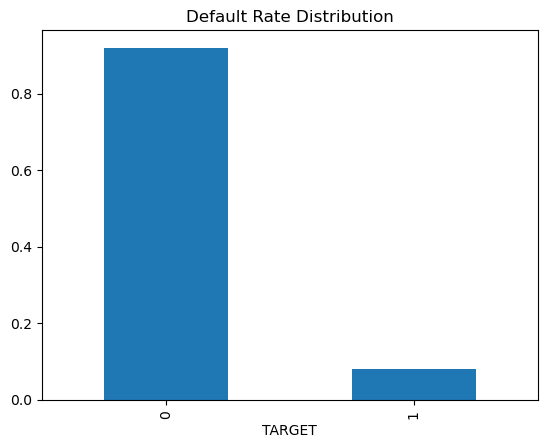

In [21]:
df["TARGET"].value_counts(normalize=True).plot(kind="bar")
plt.title("Default Rate Distribution")
plt.show()

## Feature Importance Plot

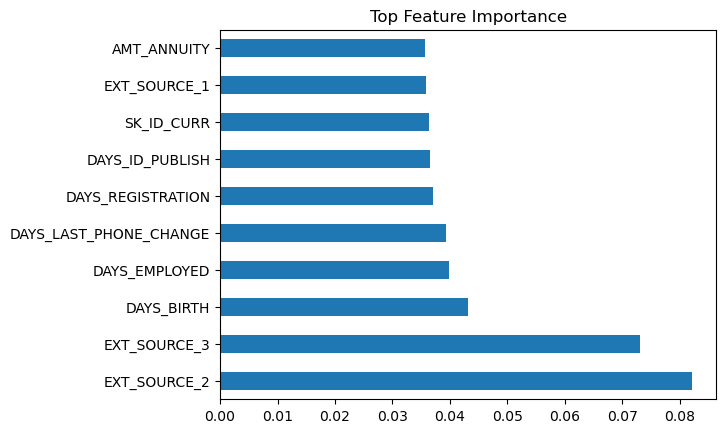

In [23]:
importance.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top Feature Importance")
plt.show()